# Permeator Probe plotting and post-processing for FESTIM simulation results. 

## Steady State Analysis 

Compare inlet, outlet, and probe surface fluxes. 

In [1]:
# PROBE IN

import numpy as np


permeation_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_results_probe_in_benchmark/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_results_probe_in_benchmark/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_results_probe_in_benchmark/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = -inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 0.30043168102711876% of inlet flux.
Advective flux at outlet is 100.44156162334701% of inlet flux.


In [ ]:
# PROBE OUT

import numpy as np


permeation_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)
inlet_advective_flux = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/inlet_advective_flux.csv", delimiter=",", names=True
)

probe_flux = permeation_flux["H_flux_surface_7"]
outlet_flux = outlet_advective_flux["H_advection_flux_surface_6"]
inlet_flux = -inlet_advective_flux["H_advection_flux_surface_4"]

# assert probe_flux + outlet_flux <= inlet_flux # mass conservation 

percent_lost_to_permeation = probe_flux/inlet_flux * 100
percent_at_outlet = outlet_flux/inlet_flux * 100

print(f"Permeation flux into probe is {percent_lost_to_permeation}% of inlet flux.")
print(f"Advective flux at outlet is {percent_at_outlet}% of inlet flux.")



Permeation flux into probe is 0.09933634204285591% of inlet flux.
Advective flux at outlet is 100.43864158030019% of inlet flux.


Calculate the pressure drop from inlet to outlet, based off of paraview-extracted data from OpenFOAM.

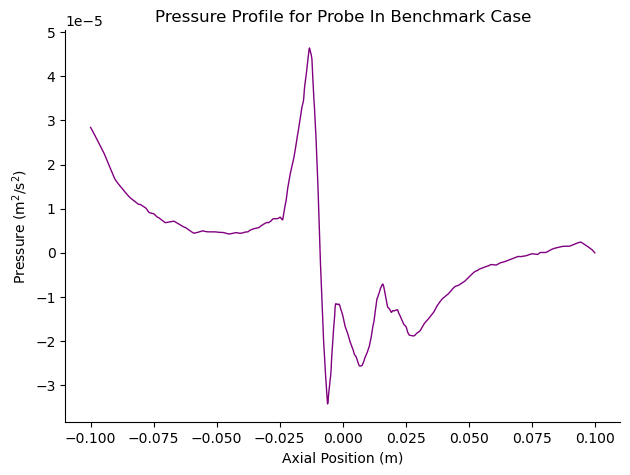

Pressure drop between inlet and outlet is 2.82994e-05 m2/s2.


In [2]:
# PROBE IN

import matplotlib.pyplot as plt

pressure_file = np.genfromtxt(
    "fixedconcentrationBC/festim_results_probe_in_benchmark/pressure.csv", delimiter=",", names=True
)
pressure = pressure_file["p"]
axial_position = pressure_file["Points1"]

plt.figure()
plt.plot(axial_position, pressure, color="purple", linewidth=1)
plt.xlabel("Axial Position (m)")
plt.ylabel(r"Pressure (m$^2$/s$^2$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Pressure Profile for Probe In Benchmark Case")
plt.show()

print(f"Pressure drop between inlet and outlet is {pressure[0]-pressure[-2]} m2/s2.")



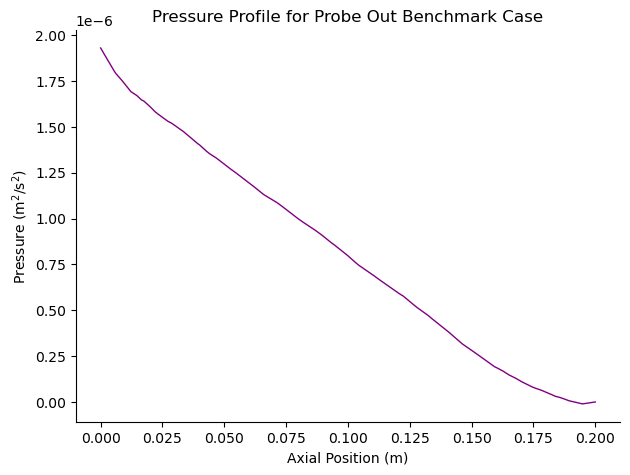

Pressure drop between inlet and outlet is 1.93036848e-06 m2/s2.


In [ ]:
# PROBE OUT

import matplotlib.pyplot as plt

pressure_file = np.genfromtxt(
    "OpenFOAM/benchmark_cases_LiPb/probe_out_kOmegaSST/pressure.csv", delimiter=",", names=True
)
pressure = pressure_file["p"]
axial_position = pressure_file["Points1"]

plt.figure()
plt.plot(axial_position, pressure, color="purple", linewidth=1)
plt.xlabel("Axial Position (m)")
plt.ylabel(r"Pressure (m$^2$/s$^2$)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.title("Pressure Profile for Probe Out Benchmark Case")
plt.show()

print(f"Pressure drop between inlet and outlet is {pressure[0]-pressure[-2]} m2/s2.")

## OpenFOAM Abacus Post Processing

Generate abacus for various flow rates and impact on permeation flux.

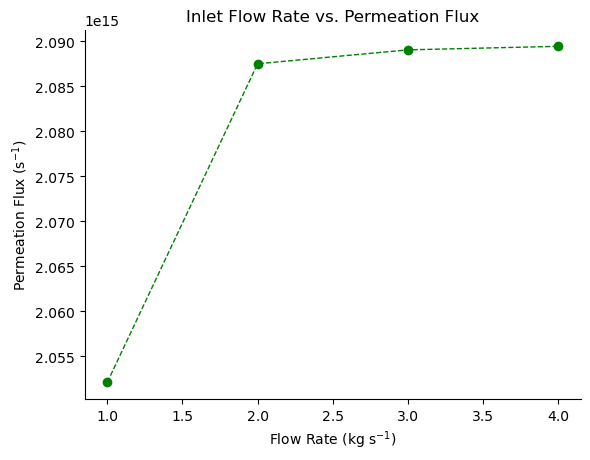

In [ ]:
# PROBE IN

flow_rates = [1,2,3,4] # kg/s 

# first flow rate is benchmark case 
permeation_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_results_probe_in_benchmark/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_results_probe_in_benchmark/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes = [permeation_1kgs["H_flux_surface_7"]]
outlet_fluxes = [outlet_1kgs["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_in/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
# plt.yscale('log')
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Probe In: Inlet Flow Rate vs. Permeation Flux")
plt.show()


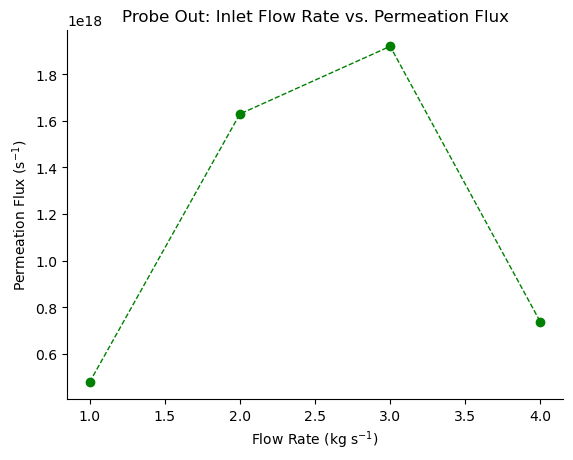

In [3]:
# PROBE OUT

flow_rates = [1,2,3,4] # kg/s 

# first flow rate is benchmark case 
permeation_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/permeation_flux.csv", delimiter=",", names=True
)
outlet_1kgs = np.genfromtxt(
    "surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_10.0_mol_m3/outlet_advective_flux.csv", delimiter=",", names=True
)

permeation_fluxes = [permeation_1kgs["H_flux_surface_7"]]
outlet_fluxes = [outlet_1kgs["H_advection_flux_surface_6"]]

for rate in flow_rates[1:]:
    file_path = f"surfaceRecomboBC/OpenFOAM_abacus_probe_out/festim_results_flow_{rate}_kg_s"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(flow_rates, permeation_fluxes, color="green", linewidth=1)
plt.plot(flow_rates, permeation_fluxes, color="green", linestyle='--', linewidth=1)
plt.xlabel(r"Flow Rate (kg s$^{-1}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
# plt.yscale('log')
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Probe Out: Inlet Flow Rate vs. Permeation Flux")
plt.show()


## FESTIM Abacus Post Processing

Generate abacus for various inlet concentrations and impact on permeation flux. 

Best Fit Line (y=1.80e+17*x^1.30)


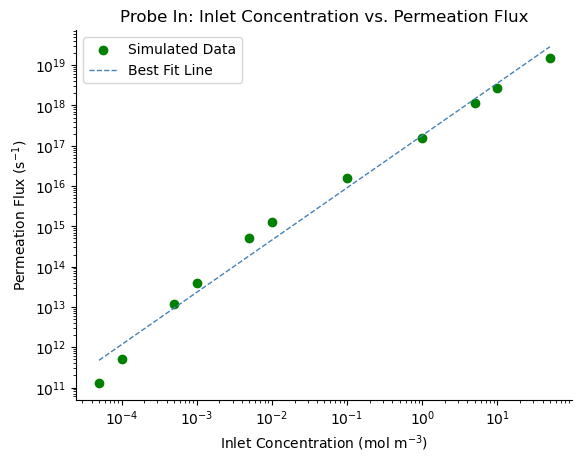

In [4]:
# PROBE IN

inlet_concentrations = mol_m3_c_in = [
    5e-5,
    1e-4,
    5e-4,
    1e-3,
    5e-3,
    1e-2,
    1e-1,
    1,
    5,
    1e1,
    5e1,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_in/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", linewidth=1, label="Simulated Data")

# best fit line 
logx = np.log(inlet_concentrations)
logy = np.log(permeation_fluxes)

coefficients = np.polyfit(logx, logy, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m
plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='steelblue',linestyle='--', linewidth=1, label="Best Fit Line") 

print(f'Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Probe In: Inlet Concentration vs. Permeation Flux")
plt.show()


Best Fit Line (y=2.59e+16*x^1.21)


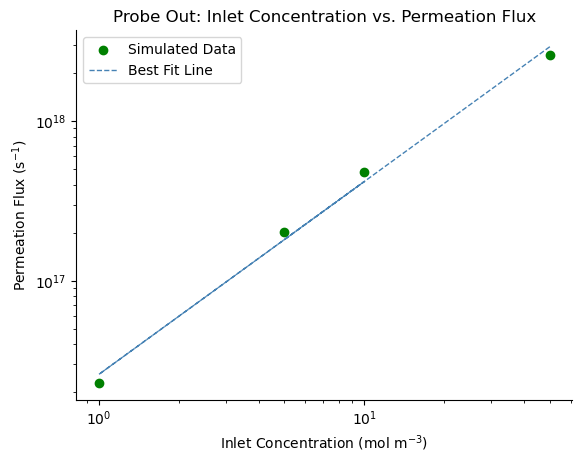

In [ ]:
# PROBE OUT

inlet_concentrations = mol_m3_c_in = [
    5,
    1e01,
    1,
    5e01,
]  # mol/m3

permeation_fluxes = []
outlet_fluxes = []

for conc in inlet_concentrations:
    file_path = f"surfaceRecomboBC/festim_abacus_probe_out/festim_results_cin_{conc}_mol_m3"
    permeation = np.genfromtxt(
        file_path+"/permeation_flux.csv", delimiter=",", names=True
    )
    outlet = np.genfromtxt(
        file_path+"/outlet_advective_flux.csv", delimiter=",", names=True
    )

    permeation_fluxes.append(permeation["H_flux_surface_7"])
    outlet_fluxes.append(outlet["H_advection_flux_surface_6"])

plt.figure()
plt.scatter(inlet_concentrations, permeation_fluxes, color="green", linewidth=1, label="Simulated Data")

# best fit line 
logx = np.log(inlet_concentrations)
logy = np.log(permeation_fluxes)

coefficients = np.polyfit(logx, logy, 1)
m = coefficients[0] # slope (exponent of the power law)
c = coefficients[1] # intercept (log of the scaling factor)

y_fit = lambda x: np.exp(c) * x**m
plt.plot(inlet_concentrations, y_fit(inlet_concentrations), color='steelblue',linestyle='--', linewidth=1, label="Best Fit Line") 

print(f'Best Fit Line (y={np.exp(c):.2e}*x^{m:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r"Inlet Concentration (mol m$^{-3}$)")
plt.ylabel(r"Permeation Flux (s$^{-1}$)")
plt.legend()
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.title("Probe Out: Inlet Concentration vs. Permeation Flux")
plt.show()